In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

### Import both btc price and sentiment data

In [2]:
btc_path = 'btc_2017_2026.csv'
sentiment_path_1 = 'transformed_2016-12-06_2020-12-22.csv'
sentiment_path_2 = 'transformed_2020-12-22_2026-04-12.csv'

In [3]:
df_btc = pd.read_csv(btc_path) 
df_sent_1 = pd.read_csv(sentiment_path_1, index_col='Unnamed: 0')
df_sent_2 = pd.read_csv(sentiment_path_2, index_col='Unnamed: 0')

In [4]:
df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3389 non-null   object 
 1   Open          3389 non-null   float64
 2   High          3389 non-null   float64
 3   Low           3389 non-null   float64
 4   Close         3389 non-null   float64
 5   Volume        3389 non-null   int64  
 6   Dividends     3389 non-null   float64
 7   Stock Splits  3389 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 211.9+ KB


In [5]:
df_sent_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7947 entries, 0 to 7946
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             7947 non-null   object 
 1   TITLE            7947 non-null   object 
 2   SUBTITLE         7866 non-null   object 
 3   PUBLISHED_ON     7947 non-null   int64  
 4   title_subtitle   7947 non-null   object 
 5   finbert_label    7947 non-null   object 
 6   finbert_score    7947 non-null   float64
 7   sentiment_score  7947 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 558.8+ KB


In [6]:
# Check the columns and dtype for both sentiment data
same_column = df_sent_1.columns.equals(df_sent_2.columns) 
same_dtype = df_sent_1.dtypes.equals(df_sent_2.dtypes)  

print(f'Both sentiment data have same columns : {same_column}.')
print(f'Both sentiment data have same dtypes : {same_dtype}.')

Both sentiment data have same columns : True.
Both sentiment data have same dtypes : True.


In [7]:
print(df_sent_1.shape, df_sent_2.shape)
print(f'Estimated concatenate total rows no. : {df_sent_1.shape[0] + df_sent_2.shape[0]}')

(7947, 8) (18407, 8)
Estimated concatenate total rows no. : 26354


In [8]:
# then combine both data 
df_sent_comb = pd.concat([df_sent_1, df_sent_2], axis = 0)

In [9]:
df_sent_comb.shape

(26354, 8)

In [10]:
df_btc.head(2)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2017-01-01 00:00:00+00:00,963.658020,1003.080017,958.698975,998.325012,147775008,0.0,0.0
1,2017-01-02 00:00:00+00:00,998.617004,1031.390015,996.702026,1021.750000,222184992,0.0,0.0


In [11]:
df_btc['proper_date'] = pd.to_datetime(df_btc['Date']).dt.date

In [12]:
df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3389 non-null   object 
 1   Open          3389 non-null   float64
 2   High          3389 non-null   float64
 3   Low           3389 non-null   float64
 4   Close         3389 non-null   float64
 5   Volume        3389 non-null   int64  
 6   Dividends     3389 non-null   float64
 7   Stock Splits  3389 non-null   float64
 8   proper_date   3389 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 238.4+ KB


In [13]:
df2 = df_sent_comb[['date','title_subtitle','sentiment_score']]
df2['date_index'] = pd.to_datetime(df2['date'],format = 'mixed')

C:\Users\user\AppData\Local\Temp\ipykernel_8980\3984889862.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['date_index'] = pd.to_datetime(df2['date'],format = 'mixed')


In [14]:
df2.set_index('date_index', inplace = True)

In [15]:
df2.shape

(26354, 3)

In [16]:
# Aggredate the daily sentiment score to mean value
result = df2.groupby(level=0).agg(sentiment = ('sentiment_score','mean'))

In [17]:
df_btc['proper_date'] = pd.to_datetime(df_btc['proper_date'], format = 'mixed')

In [18]:
df_btc.set_index('proper_date', inplace= True)

In [31]:
result_2017_2026 = result.loc['2017-01-01':'2026-04-12']
df_btc_2017_2026 = df_btc.loc['2017-01-01':'2026-04-12']

### Concatenate both data and checking correlation

In [33]:
# concat both sides based on time series index
concat = pd.concat([result_2017_2026, df_btc_2017_2026], axis = 1)

In [34]:
concat = concat.drop(columns = ['Dividends','Stock Splits'], axis = 1)

In [35]:
concat.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3389 entries, 2017-01-01 to 2026-04-12
Freq: D
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sentiment  3072 non-null   float64
 1   Date       3389 non-null   object 
 2   Open       3389 non-null   float64
 3   High       3389 non-null   float64
 4   Low        3389 non-null   float64
 5   Close      3389 non-null   float64
 6   Volume     3389 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 211.8+ KB


In [36]:
concat.to_csv('btc_sentiment_2017_2026.csv')

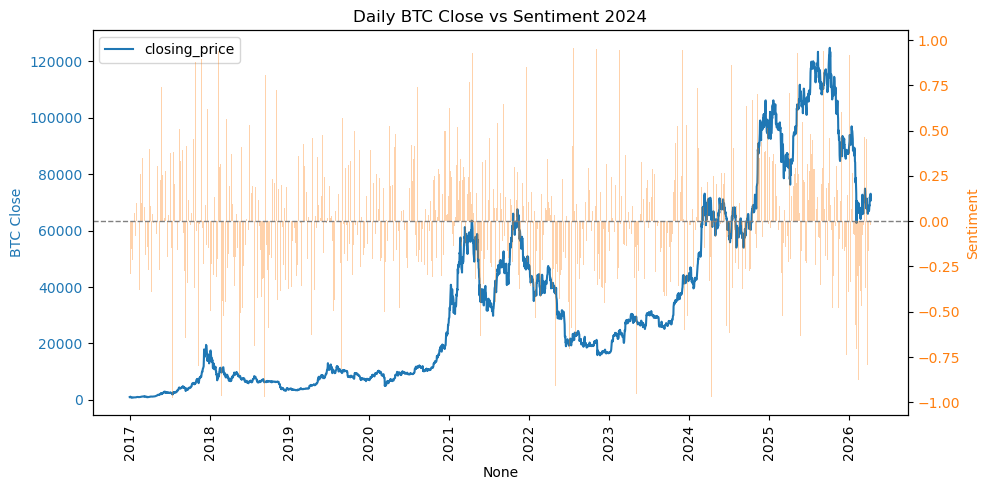

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(data=concat, x=concat.index, y='Close', ax=ax1, color='tab:blue', label='closing_price')
ax1.set_ylabel('BTC Close', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.bar(concat.index, concat['sentiment'], color='tab:orange', alpha=0.35, width=1)
ax2.set_ylabel('Sentiment', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.axhline(0, color='gray', linewidth=1, linestyle='--')  # optional but useful

ax1.set_title('Daily BTC Close vs Sentiment 2024')
ax1.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()